# 03 - Riesgo por repositorio y conclusiones

Este notebook prioriza repositorios por `risk_score`, compara indicadores clave y consolida conclusiones, limitaciones y recomendaciones de seguridad.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'results' / 'analysis.json').exists():
            return candidate
    return Path.cwd()


analysis_path = find_project_root() / 'data' / 'results' / 'analysis.json'
with analysis_path.open('r', encoding='utf-8') as f:
    analysis = json.load(f)

repo_rows = []
cicd_rows = []
for repo in analysis.get('repositories', []):
    repo_rows.append({
        'name': repo.get('name', 'unknown'),
        'vulnerabilities': repo.get('vulnerabilities', {}).get('total', 0),
        'codeql_issues': repo.get('codeql', {}).get('total_issues', 0),
        'cicd_findings': repo.get('cicd', {}).get('total_findings', 0),
        'risk_score': repo.get('metrics', {}).get('risk_score', 0.0),
        'vulnerability_density': repo.get('metrics', {}).get('vulnerability_density', 0.0),
    })

    for finding in repo.get('cicd', {}).get('items', []) or []:
        cicd_rows.append({
            'repo': repo.get('name', 'unknown'),
            'workflow': finding.get('workflow', 'unknown'),
            'issue': finding.get('issue', 'unknown'),
        })

df_repo = pd.DataFrame(repo_rows).sort_values('risk_score', ascending=False).reset_index(drop=True)
df_cicd = pd.DataFrame(cicd_rows) if cicd_rows else pd.DataFrame(columns=['repo', 'workflow', 'issue'])

df_repo


,name,vulnerabilities,codeql_issues,cicd_findings,risk_score,vulnerability_density
0,deepagents,10,11,2,23.11,0.439367
1,docs,5,0,0,9.00,0.996016
2,streaming-cookbook,4,0,0,8.00,0.444939
3,langsmith-java,2,0,0,6.00,14.285714
4,langchain,1,13,2,1.13,0.042918
5,langsmith-go,0,0,0,0.00,0.000000


In [2]:
ranking = df_repo[['name', 'risk_score']].sort_values('risk_score', ascending=False).reset_index(drop=True)
density = df_repo[['name', 'vulnerability_density']].sort_values('vulnerability_density', ascending=False).reset_index(drop=True)

display(ranking)
display(density)


,name,risk_score
0,deepagents,23.11
1,docs,9.00
2,streaming-cookbook,8.00
3,langsmith-java,6.00
4,langchain,1.13
5,langsmith-go,0.00


,name,vulnerability_density
0,langsmith-java,14.285714
1,docs,0.996016
2,streaming-cookbook,0.444939
3,deepagents,0.439367
4,langchain,0.042918
5,langsmith-go,0.000000


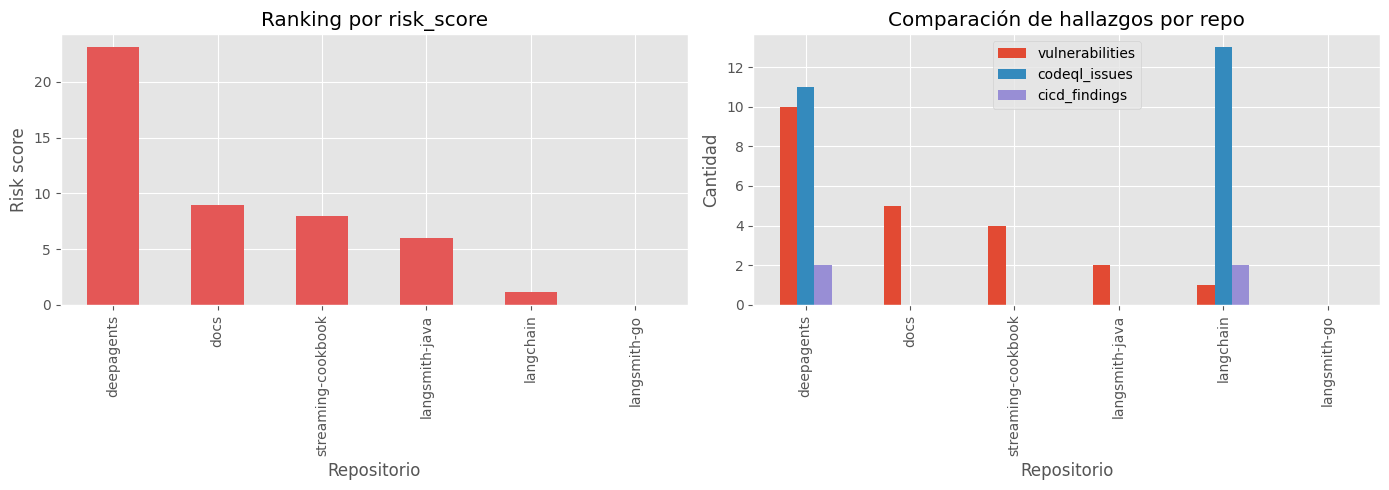

In [3]:
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_repo.plot.bar(x='name', y='risk_score', ax=axes[0], legend=False, color='#E45756')
axes[0].set_title('Ranking por risk_score')
axes[0].set_xlabel('Repositorio')
axes[0].set_ylabel('Risk score')

df_repo.set_index('name')[['vulnerabilities', 'codeql_issues', 'cicd_findings']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Comparación de hallazgos por repo')
axes[1].set_xlabel('Repositorio')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()


## Hallazgos CI/CD

In [4]:
df_cicd

,repo,workflow,issue
0,deepagents,evals.yml,Permiso 'contents: write' innecesario
1,deepagents,release_please_parse_check.yml,Job 'parse-check': usa 'npm install' en vez de...
2,langchain,_refresh_model_profiles.yml,Permiso 'contents: write' innecesario
3,langchain,refresh_model_profiles.yml,Permiso 'contents: write' innecesario


## Repositorios prioritarios

Se priorizan los repos con mayor `risk_score`, mayor volumen de High/Critical indirectamente reflejado en score y mayor densidad de vulnerabilidades.

## Conclusiones finales

- La priorización debe comenzar por los repositorios con score más alto (calculado dinámicamente en la celda siguiente).
- Conviene atacar primero vulnerabilidades High/Critical y luego Medium con fix disponible.
- Hallazgos de CI/CD (permisos y reproducibilidad) son palancas rápidas de reducción de riesgo operativo.

## Limitaciones técnicas

- CodeQL puede fallar en Java/Go por autobuild.
- CodeQL puede saltar MDX/Jupyter.
- Syft/Grype dependen de archivos de dependencias.

## Recomendaciones

- priorizar repos con mayor risk_score.
- revisar vulnerabilidades High/Critical.
- revisar permisos `contents: write` innecesarios.
- reemplazar `npm install` por `npm ci` en CI.
- actualizar dependencias con fix disponible.

In [5]:
severity_order = ['Critical', 'High', 'Medium', 'Low', 'Unknown']
severity_totals = {level: 0 for level in severity_order}

for repo in analysis.get('repositories', []):
    by_sev = repo.get('vulnerabilities', {}).get('by_severity', {}) or {}
    for level in severity_order:
        try:
            severity_totals[level] += int(by_sev.get(level, 0) or 0)
        except (TypeError, ValueError):
            severity_totals[level] += 0

top_repo = 'N/A'
top_risk = 0.0
if not df_repo.empty:
    top_repo = str(df_repo.iloc[0].get('name', 'N/A'))
    top_risk = float(df_repo.iloc[0].get('risk_score', 0.0) or 0.0)

most_common_severity = max(severity_totals, key=severity_totals.get) if severity_totals else 'Unknown'
total_high_critical = severity_totals.get('High', 0) + severity_totals.get('Critical', 0)
total_cicd = int(df_repo['cicd_findings'].sum()) if 'cicd_findings' in df_repo else 0

print('Conclusiones dinámicas (riesgo y cierre):')
print(f'- Repo con mayor risk_score: {top_repo} ({top_risk:.2f})')
print(f'- Severidad más común: {most_common_severity}')
print(f'- Total High/Critical: {total_high_critical}')
print(f'- Total hallazgos CI/CD: {total_cicd}')


Conclusiones dinámicas (riesgo y cierre):
- Repo con mayor risk_score: deepagents (23.11)
- Severidad más común: Critical
- Total High/Critical: 0
- Total hallazgos CI/CD: 4
